In [123]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [194]:
train = pd.read_csv("data/train.txt", sep=" ", header=None)

In [195]:
train.shape

(10496, 3)

In [196]:
train.head()

,0,1,2
0,939,3809,1
1,2442,5784,1
2,179,3809,1
3,857,2280,1
4,1358,5722,1


In [197]:
train.columns = ["source", "target", "label"]
train.head()

,source,target,label
0,939,3809,1
1,2442,5784,1
2,179,3809,1
3,857,2280,1
4,1358,5722,1


In [198]:
train["label"].value_counts() #the train dataset is perfectly balanced ! 

label
1    5248
0    5248
Name: count, dtype: int64

In [199]:
nodes = set(train["source"]).union(set(train["target"]))
len(nodes) #number of unique nodes 

3597

In [200]:
#we reconstruct the graph using only the edges labeled 1 

G = nx.Graph()
edges = train[train["label"] == 1][["source", "target"]].values
G.add_edges_from(edges)

In [201]:
self_loops = train[train["source"] == train["target"]]
self_loops["label"].value_counts()

#surprisingly, there are 31 true edges connecting actors to themselves

label
1    31
Name: count, dtype: int64

In [202]:
#at least temporarily, for the purpose of analyzing the graph's properties, we choose to ignore them 

train_clean = train[train["source"] != train["target"]].copy()

In [203]:
G = nx.Graph()
edges = train_clean[train_clean["label"] == 1][["source", "target"]].values
G.add_edges_from(edges)

In [204]:
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 3597
Number of edges: 5217


In [205]:
density = nx.density(G)
print("Graph density:", density) #the graph is extremely sparse

Graph density: 0.000806660351924713


In [206]:
components = list(nx.connected_components(G))
print("Number of connected components:", len(components))

#as expected, even the graph with missing edges is still fully connected 

Number of connected components: 1


In [207]:
degrees = [deg for _, deg in G.degree()]

print("Average degree:", np.mean(degrees))
print("Max degree:", np.max(degrees))
print("Min degree:", np.min(degrees))

Average degree: 2.9007506255212676
Max degree: 361
Min degree: 1


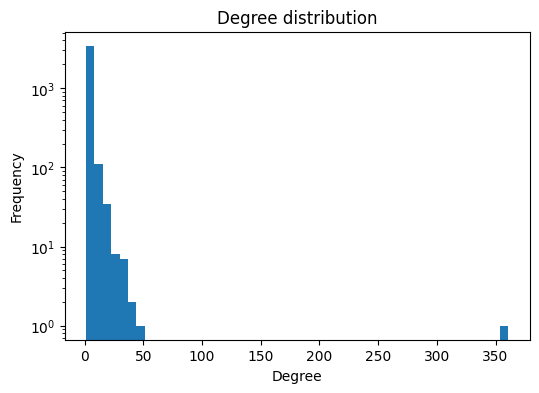

In [208]:
plt.figure(figsize=(6,4))
plt.hist(degrees, bins=50)
plt.yscale('log')
plt.title("Degree distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

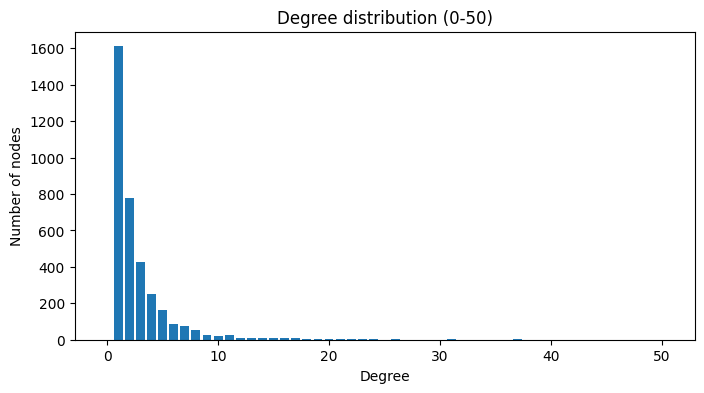

In [209]:
from collections import Counter

degree_counts = Counter(degrees)
deg_vals = list(range(0, 51))
counts = [degree_counts.get(d, 0) for d in deg_vals]

plt.figure(figsize=(8,4))
plt.bar(deg_vals, counts)
plt.title("Degree distribution (0-50)")
plt.xlabel("Degree")
plt.ylabel("Number of nodes")
plt.show()

In [210]:
max_degree_node = max(G.degree, key=lambda x: x[1])
max_degree_node #the only hub in the graph 

(3809, 361)

In [ ]:
#common neighbors

In [211]:
def common_neighbors(u, v):
    return len(list(nx.common_neighbors(G, u, v)))

In [212]:
train_clean["cn"] = train_clean.apply(lambda x: common_neighbors(x.source, x.target), axis=1)

In [213]:
print(train_clean.groupby("label")["cn"].describe())

#as expected, linked actors share, on average, more common neighbors than unlinked actors
#but in both cases, the third quartile is 0, so having zero common neighbors is not a discriminating feature

        count      mean       std  min  25%  50%  75%  max
label                                                     
0      5248.0  0.014101  0.117917  0.0  0.0  0.0  0.0  1.0
1      5217.0  0.112708  0.372494  0.0  0.0  0.0  0.0  5.0


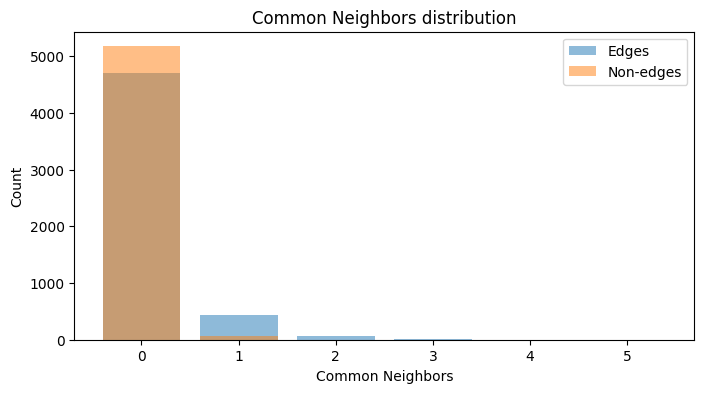

In [214]:
cn_0 = Counter(train_clean[train_clean["label"] == 0]["cn"])
cn_1 = Counter(train_clean[train_clean["label"] == 1]["cn"])
max_cn = int(train_clean["cn"].max())
x = list(range(0, max_cn + 1))
counts_0 = [cn_0.get(i, 0) for i in x]
counts_1 = [cn_1.get(i, 0) for i in x]

plt.figure(figsize=(8,4))
plt.bar(x, counts_1, alpha=0.5, label="Edges")
plt.bar(x, counts_0, alpha=0.5, label="Non-edges")
plt.xlabel("Common Neighbors")
plt.ylabel("Count")
plt.title("Common Neighbors distribution")
plt.xticks(x)
plt.legend()
plt.show()

In [217]:
(train_clean[train_clean["cn"] > 0]["label"].mean())

#when the number of common neighbors is non-zero, the probability of a link rises to 87%

0.8721934369602763

In [ ]:
#Adamic-Adar

In [218]:
def adamic_adar(u, v):
    return sum(1 / np.log(G.degree(w)) for w in nx.common_neighbors(G, u, v))

In [219]:
train_clean["aa"] = train_clean.apply(lambda x: adamic_adar(x.source, x.target), axis=1)

In [ ]:
print(train_clean.groupby("label")["aa"].describe())

#as expected, linked actors share, on average, a higher Adamic-Adar score than unlinked actors
#but in both cases, the third quartile is 0, so having zero common neighbors is not a discriminating feature

        count      mean       std  min  25%  50%  75%       max
label                                                          
0      5248.0  0.004273  0.047612  0.0  0.0  0.0  0.0  1.442695
1      5217.0  0.061171  0.226115  0.0  0.0  0.0  0.0  2.885390


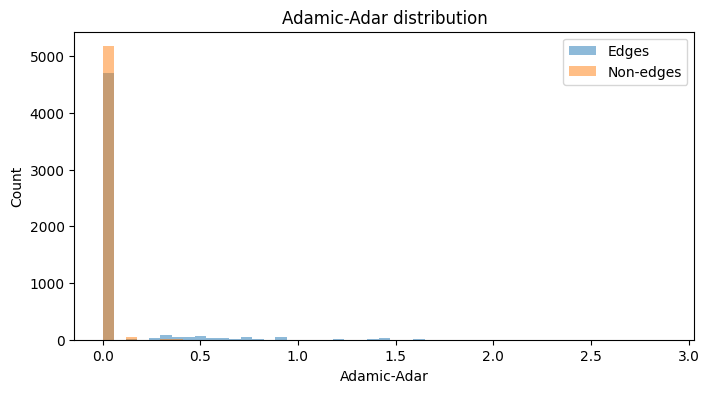

In [221]:
aa_0 = train_clean[train_clean["label"] == 0]["aa"]
aa_1 = train_clean[train_clean["label"] == 1]["aa"]

bins = np.linspace(0, train_clean["aa"].max(), 50)
plt.figure(figsize=(8,4))
plt.hist(aa_1, bins=bins, alpha=0.5, label="Edges")
plt.hist(aa_0, bins=bins, alpha=0.5, label="Non-edges")
plt.xlabel("Adamic-Adar")
plt.ylabel("Count")
plt.title("Adamic-Adar distribution")
plt.legend()
plt.show()

In [224]:
(train_clean[train_clean["aa"] > 0]["label"].mean())

#by definition, we obtain the same probability estimate as when using the number of common neighbors

0.8721934369602763

In [ ]:
#Jaccard

In [225]:
def jaccard(u, v):
    neighbors_u = set(G.neighbors(u))
    neighbors_v = set(G.neighbors(v))
    
    intersection = len(neighbors_u & neighbors_v)
    union = len(neighbors_u | neighbors_v)
    
    if union == 0:
        return 0
    
    return intersection / union

In [226]:
train_clean["jaccard"] = train_clean.apply(lambda x: jaccard(x.source, x.target), axis=1)

In [227]:
print(train_clean.groupby("label")["jaccard"].describe())

#if we take the average as an indicator, Jaccard is a much less discriminative feature than the previous two

        count      mean       std  min  25%  50%  75%  max
label                                                     
0      5248.0  0.005952  0.065847  0.0  0.0  0.0  0.0  1.0
1      5217.0  0.007638  0.029751  0.0  0.0  0.0  0.0  0.4


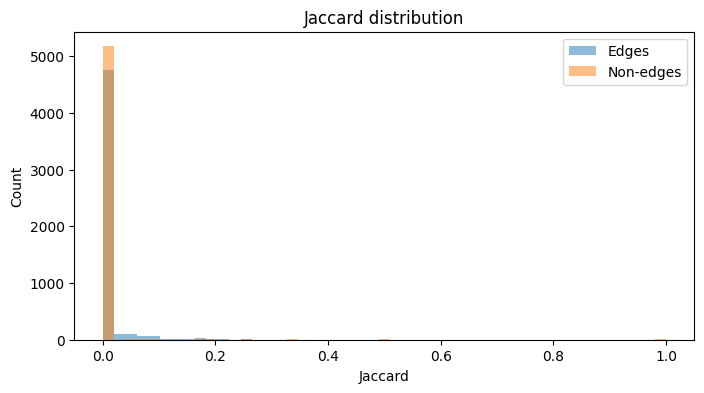

In [228]:
jac_0 = train_clean[train_clean["label"] == 0]["jaccard"]
jac_1 = train_clean[train_clean["label"] == 1]["jaccard"]

bins = np.linspace(0, train_clean["jaccard"].max(), 50)
plt.figure(figsize=(8,4))
plt.hist(jac_1, bins=bins, alpha=0.5, label="Edges")
plt.hist(jac_0, bins=bins, alpha=0.5, label="Non-edges")
plt.xlabel("Jaccard")
plt.ylabel("Count")
plt.title("Jaccard distribution")
plt.legend()
plt.show()

In [229]:
(train_clean[train_clean["jaccard"] > 0]["label"].mean())

#a non-zero Jaccard coefficient is equivalent to having at least one common neighbor

0.8721934369602763

In [ ]:
#preferential attachment

In [231]:
def preferential_attachment(u, v):
    return G.degree(u) * G.degree(v)

In [232]:
train_clean["pa"] = train_clean.apply(lambda x: preferential_attachment(x.source, x.target), axis=1)

In [ ]:
print(train_clean.groupby("label")["pa"].describe())

#node pairs with high preferential attachment are far more likely to correspond to true edges

        count        mean         std  min  25%   50%   75%      max
label                                                               
0      5248.0    7.510671   16.199063  1.0  2.0   4.0   8.0    555.0
1      5217.0  108.307265  374.968923  2.0  8.0  21.0  66.0  13357.0


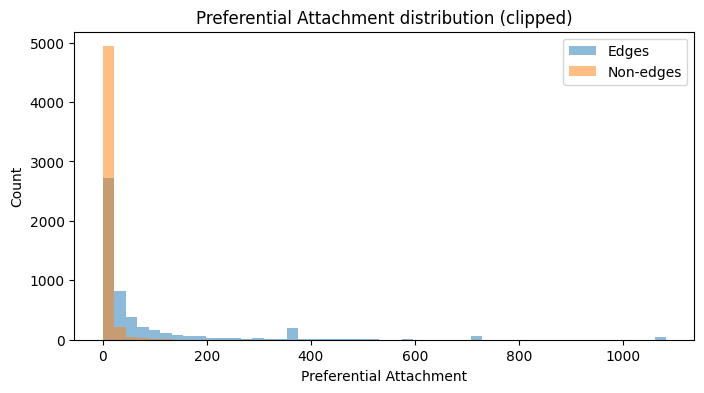

In [234]:
pa_0 = train_clean[train_clean["label"] == 0]["pa"]
pa_1 = train_clean[train_clean["label"] == 1]["pa"]

bins = np.linspace(0, np.percentile(train_clean["pa"], 99), 50)
plt.figure(figsize=(8,4))
plt.hist(pa_1, bins=bins, alpha=0.5, label="Edges")
plt.hist(pa_0, bins=bins, alpha=0.5, label="Non-edges")
plt.xlabel("Preferential Attachment")
plt.ylabel("Count")
plt.title("Preferential Attachment distribution (clipped)")
plt.legend()
plt.show()

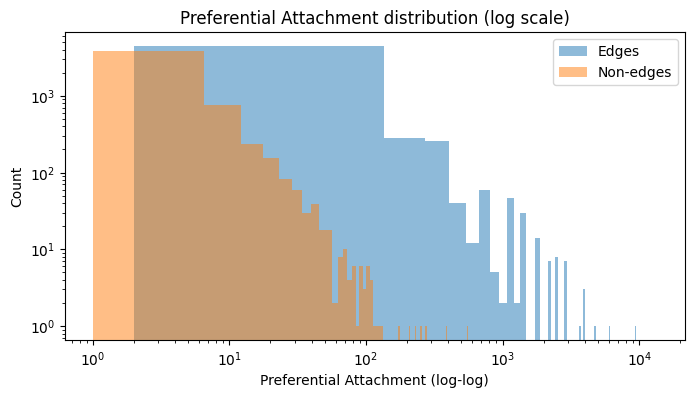

In [235]:
plt.figure(figsize=(8,4))
plt.hist(pa_1, bins=100, alpha=0.5, label="Edges")
plt.hist(pa_0, bins=100, alpha=0.5, label="Non-edges")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Preferential Attachment (log-log)")
plt.ylabel("Count")
plt.title("Preferential Attachment distribution (log scale)")
plt.legend()
plt.show()

In [236]:
print((train_clean[train_clean["pa"] > 0]["label"].mean()))
print((train_clean[train_clean["pa"] > 5]["label"].mean()))
print((train_clean[train_clean["pa"] > 50]["label"].mean()))
print((train_clean[train_clean["pa"] > 100]["label"].mean()))
print((train_clean[train_clean["pa"] > 200]["label"].mean()))

#while low preferential attachment values do not strongly discriminate edges from non-edges, high values 
#are almost exclusively associated with true edges, indicating a strong effect of hubs in link formation

0.4985188724319159
0.7012224938875306
0.9514443761524278
0.9787878787878788
0.9898477157360406


In [237]:
features = ["cn", "aa", "jaccard", "pa"]
corr = train_clean[features].corr()

print(corr)

               cn        aa   jaccard        pa
cn       1.000000  0.887526  0.494609  0.162822
aa       0.887526  1.000000  0.382616  0.146064
jaccard  0.494609  0.382616  1.000000 -0.005972
pa       0.162822  0.146064 -0.005972  1.000000


In [239]:
clustering = nx.average_clustering(G)
print("Average clustering coefficient:", clustering)

Average clustering coefficient: 0.019560058406301813


In [240]:
degrees_dict = dict(G.degree())
train_clean["deg_u"] = train_clean["source"].map(degrees_dict)
train_clean["deg_v"] = train_clean["target"].map(degrees_dict)
train_clean["max_deg"] = train_clean[["deg_u", "deg_v"]].max(axis=1)

In [241]:
print(train_clean.groupby("label")["max_deg"].describe())

#edges tend to involve at least one high-degree node, which is consistent with preferential attachment
#results but highlights that even a single high-degree node is sufficient to increase the probability 
#of a link

        count       mean        std  min  25%  50%   75%    max
label                                                          
0      5248.0   4.057927   4.361552  1.0  2.0  3.0   5.0   48.0
1      5217.0  34.933870  89.360263  2.0  4.0  8.0  16.0  361.0


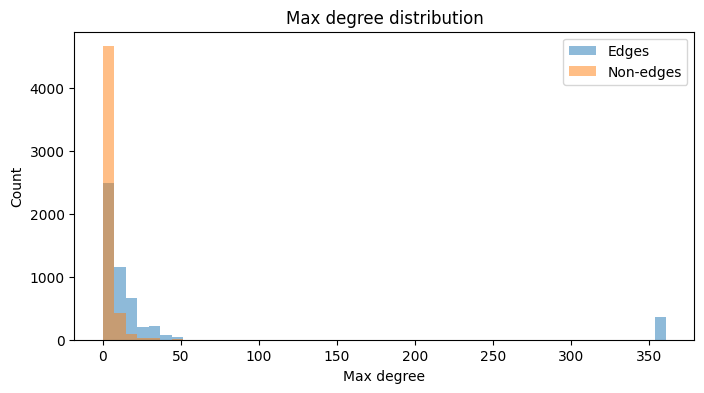

In [242]:
maxdeg_0 = train_clean[train_clean["label"] == 0]["max_deg"]
maxdeg_1 = train_clean[train_clean["label"] == 1]["max_deg"]

bins = np.linspace(0, np.percentile(train_clean["max_deg"], 99), 50)
plt.figure(figsize=(8,4))
plt.hist(maxdeg_1, bins=bins, alpha=0.5, label="Edges")
plt.hist(maxdeg_0, bins=bins, alpha=0.5, label="Non-edges")
plt.xlabel("Max degree")
plt.ylabel("Count")
plt.title("Max degree distribution")
plt.legend()
plt.show()

In [244]:
print((train_clean[train_clean["max_deg"] > 1]["label"].mean()))
print((train_clean[train_clean["max_deg"] > 10]["label"].mean()))
print((train_clean[train_clean["max_deg"] > 50]["label"].mean()))

#the presence of highly connected nodes is a strong predictor of link formation, but this effect is 
#partly amplified by the random sampling of negative pairs which rarely include high-degree nodes 

0.5534104168876631
0.8628246753246753
1.0
